<a href="https://colab.research.google.com/github/pughbrennan02-ai/Diamond-Assignment/blob/main/Homework3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

In [3]:
iris = load_iris()
X = iris.data
y = iris.target

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (150, 4)
Target vector shape: (150,)


In [4]:
k_range = range(1, 31)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=10, scoring="accuracy")
    k_scores.append(scores.mean())

optimal_k = list(k_range)[k_scores.index(max(k_scores))]
optimal_accuracy = max(k_scores)

print(f"Optimal k: {optimal_k}")
print(f"Cross-validated accuracy: {optimal_accuracy:.4f}")

Optimal k: 13
Cross-validated accuracy: 0.9800


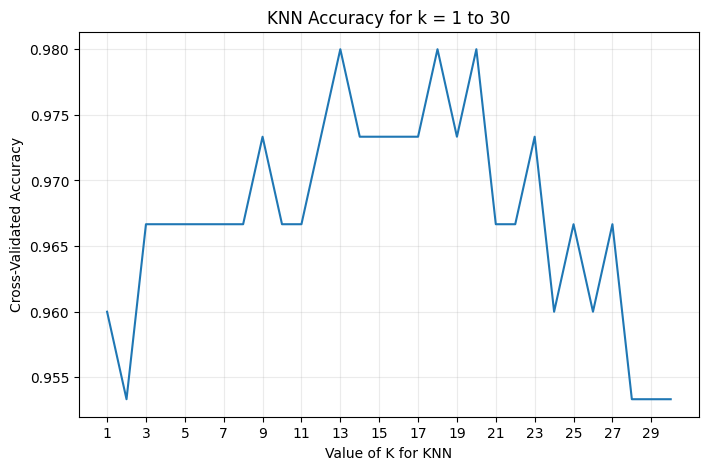

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), k_scores)
plt.xlabel("Value of K for KNN")
plt.ylabel("Cross-Validated Accuracy")
plt.title("KNN Accuracy for k = 1 to 30")
plt.xticks(range(1, 31, 2))
plt.grid(alpha=0.25)
plt.show()

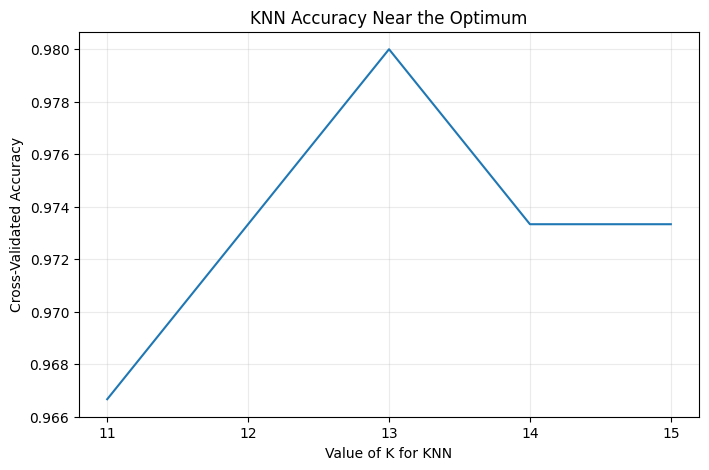

In [6]:
zoom_k = list(range(11, 16))
zoom_scores = [k_scores[k - 1] for k in zoom_k]

plt.figure(figsize=(8, 5))
plt.plot(zoom_k, zoom_scores)
plt.xlabel("Value of K for KNN")
plt.ylabel("Cross-Validated Accuracy")
plt.title("KNN Accuracy Near the Optimum")
plt.xticks(zoom_k)
plt.grid(alpha=0.25)
plt.show()

In [7]:
parameter_grid = {"n_neighbors": list(range(1, 31))}

grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=parameter_grid,
    cv=10,
    scoring="accuracy",
)
grid.fit(X, y)

print("Best parameter:", grid.best_params_)
print(f"Best cross-validated accuracy: {grid.best_score_:.4f}")

Best parameter: {'n_neighbors': 13}
Best cross-validated accuracy: 0.9800
